<a href="https://colab.research.google.com/github/Shikha9557/Deep-Learning-Exp/blob/main/exp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EXPERIMENT 2: ANN for Classification and Regression**
**Part A — ANN Classification**

Here we create a small Student Performance Classification Dataset.

The ANN will predict whether a student Passes (1) or Fails (0) based on:

Study Hours

* Attendance
* Internal Marks
* Assignment Score

TensorFlow Version: 2.20.0

Student Classification Dataset:
    Study_Hours  Attendance  Internal_Marks  Assignment_Score  Pass
0             1          50              35                40     0
1             2          55              40                45     0
2             3          60              45                50     0
3             4          65              50                55     1
4             5          70              55                60     1
5             6          75              60                65     1
6             7          80              65                70     1
7             8          90              75                85     1
8             2          52              38                42     0
9             3          62              44                48     0
10            5          72              57                62     1
11            6          78              63                68     1
12            7          85              68             

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.3684 - loss: 0.6627 - val_accuracy: 0.6000 - val_loss: 0.6452
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5789 - loss: 0.6458 - val_accuracy: 0.8000 - val_loss: 0.6256
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7368 - loss: 0.6316 - val_accuracy: 1.0000 - val_loss: 0.6062
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8421 - loss: 0.6173 - val_accuracy: 1.0000 - val_loss: 0.5873
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8421 - loss: 0.6022 - val_accuracy: 1.0000 - val_loss: 0.5702
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8421 - loss: 0.5888 - val_accuracy: 1.0000 - val_loss: 0.5539
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8421 - loss: 0.5757 - val_accuracy: 1.0000 - val_loss: 0.5379
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8421 - loss: 0.5643 - val_accuracy: 1.0000 - val_loss: 0.5217

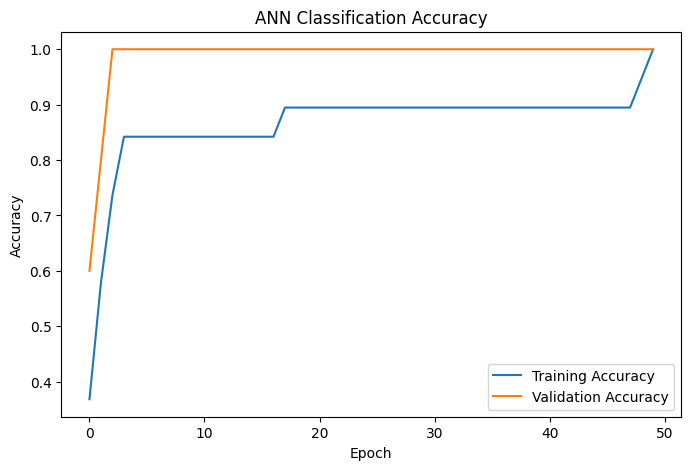

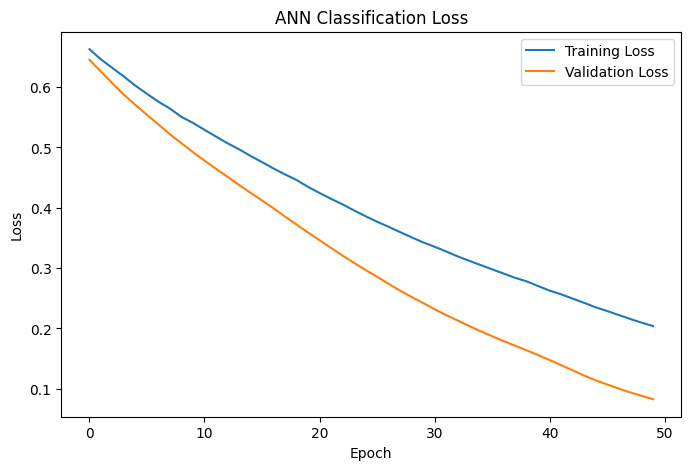

In [ ]:
# ============================================================
# EXPERIMENT 2
# ANN MODEL FOR CLASSIFICATION AND REGRESSION
# ============================================================

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow Version:", tf.__version__)


# ============================================================
# PART A: ANN CLASSIFICATION
# ============================================================

# Create Classification Dataset
data = {
    'Study_Hours': [1,2,3,4,5,6,7,8,2,3,
                    5,6,7,8,1,4,5,7,3,6,
                    8,2,4,6,7,5,3,8,4,7],

    'Attendance': [50,55,60,65,70,75,80,90,52,62,
                   72,78,85,92,45,68,74,88,58,82,
                   95,54,66,76,86,71,61,94,69,89],

    'Internal_Marks': [35,40,45,50,55,60,65,75,38,44,
                       57,63,68,78,30,52,59,72,42,67,
                       80,37,49,62,70,56,46,82,53,73],

    'Assignment_Score': [40,45,50,55,60,65,70,85,42,48,
                         62,68,75,88,35,58,64,80,46,72,
                         90,44,53,67,78,61,51,92,57,83],

    'Pass': [0,0,0,1,1,1,1,1,0,0,
             1,1,1,1,0,1,1,1,0,1,
             1,0,1,1,1,1,0,1,1,1]
}

df = pd.DataFrame(data)

print("\nStudent Classification Dataset:")
print(df)

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# Separate Input and Output
# ============================================================

X = df[['Study_Hours',
        'Attendance',
        'Internal_Marks',
        'Assignment_Score']]

y = df['Pass']


# ============================================================
# Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# Feature Scaling
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ============================================================
# Create ANN Model
# ============================================================

classification_model = Sequential([

    # Input + Hidden Layer
    Dense(16, activation='relu',
          input_shape=(X_train.shape[1],)),

    # Hidden Layer
    Dense(8, activation='relu'),

    # Output Layer
    Dense(1, activation='sigmoid')
])


# Display model
classification_model.summary()


# ============================================================
# Compile Model
# ============================================================

classification_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ============================================================
# Train Model
# ============================================================

history = classification_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)


# ============================================================
# Evaluate Model
# ============================================================

loss, accuracy = classification_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nClassification Accuracy:",
      round(accuracy * 100, 2), "%")


# ============================================================
# Prediction
# ============================================================

probability = classification_model.predict(X_test)

y_pred = (probability >= 0.5).astype(int).flatten()

print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)


# ============================================================
# Accuracy Score
# ============================================================

acc = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:",
      round(acc * 100, 2), "%")


# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# Accuracy Graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("ANN Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


# ============================================================
# Loss Graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("ANN Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

**Part B — ANN Regression**

For regression, we'll use a Student Marks Dataset.

The ANN will predict the Final Marks based on:

* Study Hours
* Attendance
* Assignment Marks
* Internal Marks


Student Regression Dataset:
    Study_Hours  Attendance  Assignment_Marks  Internal_Marks  Final_Marks
0             1          50                40              35           38
1             2          55                45              40           43
2             3          60                50              45           48
3             4          65                55              50           54
4             5          70                60              55           59
5             6          75                65              60           65
6             7          80                70              65           70
7             8          90                85              75           82
8             2          52                42              38           41
9             3          62                48              44           48
10            4          66                54              49           52
11            5          72                62              57          

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 3978.5137 - mae: 61.4228 - val_loss: 4848.2925 - val_mae: 68.3959
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 3970.1155 - mae: 61.3488 - val_loss: 4839.6836 - val_mae: 68.3336
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3962.0422 - mae: 61.2780 - val_loss: 4831.6250 - val_mae: 68.2746
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 3954.7937 - mae: 61.2117 - val_loss: 4823.7910 - val_mae: 68.2165
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 3947.0264 - mae: 61.1386 - val_loss: 4815.6353 - val_mae: 68.1571
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 3939.6904 - mae: 61.0757 - val_loss: 4807.4023 - val_mae: 68.0969
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3932.0083 - mae: 61.0058 - val_loss: 4798.9131 - val_mae: 68.0350
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3924.4304 - mae: 60.9364 - val_loss: 4790.0938 - val_mae: 67.9716
Epoch 9

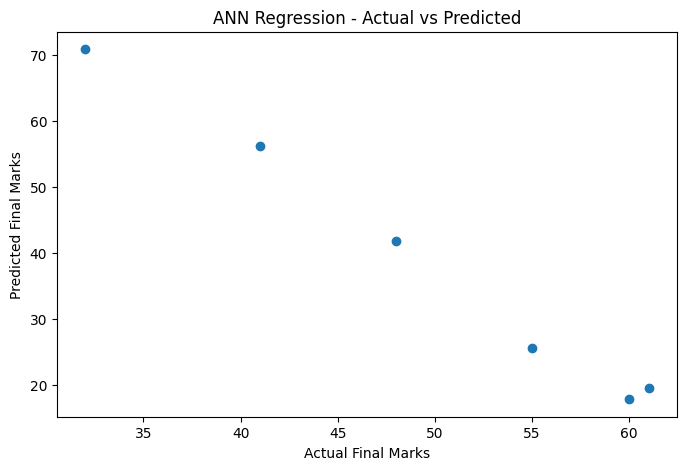

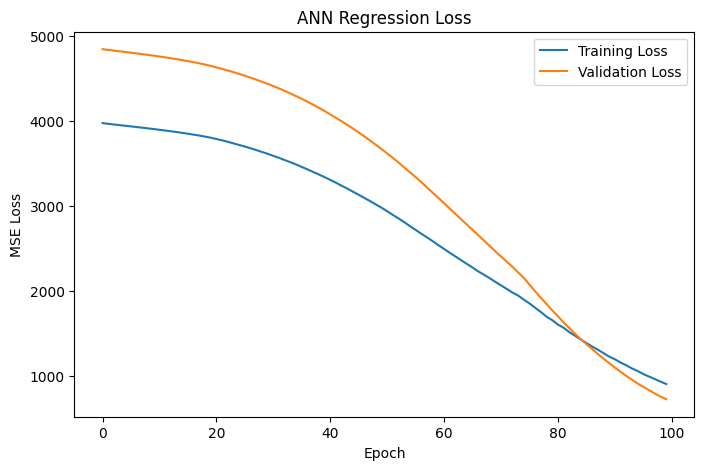

In [ ]:
# ============================================================
# PART B: ANN REGRESSION
# ============================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


# ============================================================
# Create Regression Dataset
# ============================================================

regression_data = {

    'Study_Hours': [
        1,2,3,4,5,6,7,8,2,3,
        4,5,6,7,8,1,3,5,7,4,
        6,8,2,4,6,7,3,5,8,6
    ],

    'Attendance': [
        50,55,60,65,70,75,80,90,52,62,
        66,72,78,85,92,45,58,74,88,68,
        82,95,54,69,76,86,61,71,94,80
    ],

    'Assignment_Marks': [
        40,45,50,55,60,65,70,85,42,48,
        54,62,68,75,88,35,46,64,80,58,
        72,90,44,57,67,78,51,61,92,73
    ],

    'Internal_Marks': [
        35,40,45,50,55,60,65,75,38,44,
        49,57,63,68,78,30,42,59,72,52,
        67,80,37,53,62,70,46,56,82,69
    ],

    'Final_Marks': [
        38,43,48,54,59,65,70,82,41,48,
        52,60,66,73,84,32,43,61,76,55,
        69,86,41,55,65,74,49,60,87,72
    ]
}


df_reg = pd.DataFrame(regression_data)

print("\nStudent Regression Dataset:")
print(df_reg)

print("\nDataset Shape:")
print(df_reg.shape)


# ============================================================
# Separate Input and Target
# ============================================================

X = df_reg[
    [
        'Study_Hours',
        'Attendance',
        'Assignment_Marks',
        'Internal_Marks'
    ]
]

y = df_reg['Final_Marks']


# ============================================================
# Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# Feature Scaling
# ============================================================

scaler_reg = StandardScaler()

X_train = scaler_reg.fit_transform(X_train)
X_test = scaler_reg.transform(X_test)


# ============================================================
# Build ANN Regression Model
# ============================================================

regression_model = Sequential([

    Dense(
        16,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    Dense(
        8,
        activation='relu'
    ),

    # Output layer
    Dense(
        1
    )
])


# Display model
regression_model.summary()


# ============================================================
# Compile Model
# ============================================================

regression_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


# ============================================================
# Train Model
# ============================================================

reg_history = regression_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)


# ============================================================
# Evaluate Model
# ============================================================

loss, mae = regression_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTest MSE:", loss)
print("Test MAE:", mae)


# ============================================================
# Prediction
# ============================================================

y_pred = regression_model.predict(X_test).flatten()


print("\nActual Final Marks:")
print(y_test.values)

print("\nPredicted Final Marks:")
print(np.round(y_pred, 2))


# ============================================================
# Regression Metrics
# ============================================================

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\nRegression Results")
print("-------------------------")
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("MAE  :", round(mae, 2))
print("R2   :", round(r2, 2))


# ============================================================
# Actual vs Predicted
# ============================================================

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")

plt.title(
    "ANN Regression - Actual vs Predicted"
)

plt.show()


# ============================================================
# Regression Loss Graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    reg_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    reg_history.history['val_loss'],
    label='Validation Loss'
)

plt.title("ANN Regression Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()